In [14]:
pip install "git+https://github.com/JosephMatatyaou/STA199REU.git#subdirectory=Package"

  Cloning https://github.com/JosephMatatyaou/STA199REU.git to /private/var/folders/fv/hp4twm4n1nvfw6395l5_zmgw0000gp/T/pip-req-build-03o9x7pt
  Running command git clone --filter=blob:none --quiet https://github.com/JosephMatatyaou/STA199REU.git /private/var/folders/fv/hp4twm4n1nvfw6395l5_zmgw0000gp/T/pip-req-build-03o9x7pt
  Resolved https://github.com/JosephMatatyaou/STA199REU.git to commit 17f4184943e3ffaf951b6f0d582b9306c56bfd35
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


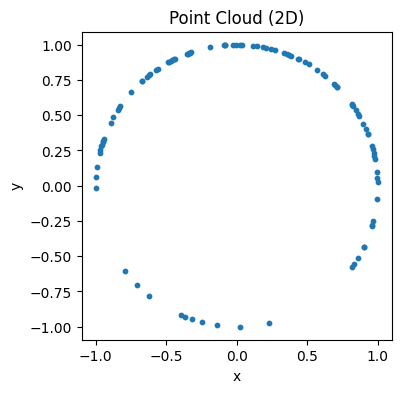

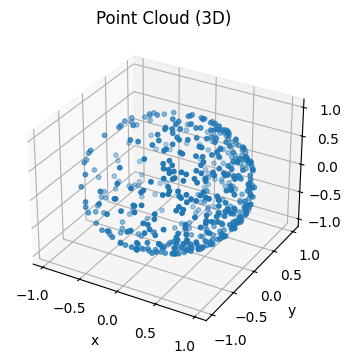

In [15]:
import numpy as np
import ecc_vr as vr
import matplotlib.pyplot as plt


def sample_manifold(shape: str, n: int, rng: np.random.Generator) -> np.ndarray:
    """
    Draw n fresh points from the named manifold.
    Supported: 'sphere', 'torus', 'circle', 'torus_flat'
    """
    shape = shape.lower().strip()

    if shape == "sphere":
        v = rng.normal(size=(n, 3))
        v /= np.linalg.norm(v, axis=1, keepdims=True)
        return v                                    # unit S^2 in R^3

    if shape == "torus":
        return unif_torus_points(n, R=2.0, r=0.7, rng=rng)   # standard torus

    if shape == "circle":
        theta = rng.uniform(0, 2 * np.pi, size=n)
        return np.column_stack([np.cos(theta), np.sin(theta)])  # unit S^1 in R^2

    if shape == "torus_flat":
        # Flat torus: sample (theta, phi) in [0,2pi)^2 — ignores curvature bias
        theta = rng.uniform(0, 2 * np.pi, size=n)
        phi   = rng.uniform(0, 2 * np.pi, size=n)
        R, r  = 2.0, 0.7
        return np.column_stack([
            (R + r * np.cos(theta)) * np.cos(phi),
            (R + r * np.cos(theta)) * np.sin(phi),
            r * np.sin(theta),
        ])

    raise ValueError(f"Unknown shape: {shape!r}. "
                     "Choose 'sphere', 'torus', 'circle', or 'torus_flat'.")

def unif_torus_points(n: int, R: float, r: float, rng: np.random.Generator) -> np.ndarray:
    """Uniform samples on a torus via acceptance-rejection."""
    out = np.empty((n, 3), dtype=float)
    phi = rng.uniform(0, 2 * np.pi, size=n)
    j = 0
    M = R + r
    while j < n:
        theta = rng.uniform(0, 2 * np.pi)
        h = R + r * np.cos(theta)
        if rng.uniform(0, M) <= h:
            out[j, 0] = h * np.cos(phi[j])
            out[j, 1] = h * np.sin(phi[j])
            out[j, 2] = r * np.sin(theta)
            j += 1
    return out


def hemisphere_biased_hypersphere(
    n_points,
    d,
    p=0.8,
    r=1.0,
    center=None,
    direction=None,
    seed=None,
    shuffle=True,
):
    # p = fraction of points in the hemisphere
    # {x : <x - center, direction> >= 0}

    if d < 2:
        raise ValueError("d must be at least 2")
    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1")

    rng = np.random.default_rng(seed)

    if direction is None:
        direction = np.zeros(d)
        direction[0] = 1.0

    direction = np.asarray(direction, dtype=float)
    if direction.shape != (d,):
        raise ValueError(f"direction must have shape ({d},)")

    direction_norm = np.linalg.norm(direction)
    if direction_norm == 0:
        raise ValueError("direction must be non-zero")
    direction = direction / direction_norm

    def sample_uniform_sphere(m):
        X = rng.normal(size=(m, d))
        norms = np.linalg.norm(X, axis=1, keepdims=True)

        while np.any(norms == 0):
            bad = norms[:, 0] == 0
            X[bad] = rng.normal(size=(bad.sum(), d))
            norms[bad] = np.linalg.norm(X[bad], axis=1, keepdims=True)

        return X / norms

    n_side = int(round(p * n_points))
    n_other = n_points - n_side

    # sample points for the chosen hemisphere
    X_side = sample_uniform_sphere(n_side)
    dots_side = X_side @ direction
    X_side[dots_side < 0] *= -1.0

    # sample points for the opposite hemisphere
    X_other = sample_uniform_sphere(n_other)
    dots_other = X_other @ direction
    X_other[dots_other > 0] *= -1.0

    X = np.vstack([X_side, X_other])

    if shuffle:
        rng.shuffle(X, axis=0)

    X *= r

    if center is not None:
        center = np.asarray(center, dtype=float)
        if center.shape != (d,):
            raise ValueError(f"center must have shape ({d},)")
        X += center

    return X

C = hemisphere_biased_hypersphere(
    n_points = 100,
    d = 2,
    p = 0.8,
    direction = [0,1],
    seed = None,
)
fig = plt.figure(figsize = (4,4))
ax = fig.add_subplot(111)
vr.plot_point_cloud_on_ax(ax, C, 2)
plt.show()

C2 = hemisphere_biased_hypersphere(
    n_points=500,
    d=3,
    p=0.8,          # 80% on one side
    direction=[1, 0, 0],      # which side
    seed=None,
)
fig2 = plt.figure(figsize = (4,4))
ax2 = fig2.add_subplot(111, projection = '3d')
vr.plot_point_cloud_on_ax(ax2, C2, 3)
plt.show()

In [16]:
def count_edges(X: np.ndarray, t: float, D: np.ndarray | None = None, d: int | None = None, return_density: bool = False):
    X = np.asarray(X, dtype=float)

    n = X.shape[0]

    if d is None:
        d = X.shape[1]  # intrinsic dimension (we’ll set this to 2 later)

    epsilon = t / (n ** (1.0 / d))

    if D is None:
        D = vr.pairwise_dist(X)

    edges = np.count_nonzero(np.triu(D <= epsilon, k=1))

    if return_density:
        return edges / (n * (n - 1) / 2)

    return edges

In [17]:
import math

def hypersphere_surface_area(d, r=1.0):
    if d < 2:
        raise ValueError("d must be at least 2")
    if r <= 0:
        raise ValueError("r must be positive")

    log_area = (
        math.log(2.0)
        + 0.5 * d * math.log(math.pi)
        + (d - 1) * math.log(r)
        - math.lgamma(d / 2.0)
    )
    return math.exp(log_area)


def hemisphere_biased_hypersphere_pdf(
    C,
    p = 0.8,
    r = 1.0,
    center = None,
    direction = None,
    tol = 1e-8,
):
    C = np.asarray(C, dtype=float)

    if C.ndim != 2:
        raise ValueError("C must have shape (n_points, d)")

    n_points, d = C.shape

    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1")

    if center is None:
        center = np.zeros(d)
    center = np.asarray(center, dtype=float)
    if center.shape != (d,):
        raise ValueError(f"center must have shape ({d},)")

    if direction is None:
        direction = np.zeros(d)
        direction[0] = 1.0
    direction = np.asarray(direction, dtype=float)
    if direction.shape != (d,):
        raise ValueError(f"direction must have shape ({d},)")

    direction_norm = np.linalg.norm(direction)
    if direction_norm == 0:
        raise ValueError("direction must be non-zero")
    direction = direction / direction_norm

    shifted = C - center
    radii = np.linalg.norm(shifted, axis=1)
    on_sphere = np.abs(radii - r) <= tol

    dots = shifted @ direction
    area = hypersphere_surface_area(d, r)

    pdf_vals = np.zeros(n_points, dtype=float)
    pdf_vals[on_sphere & (dots >= 0)] = 2.0 * p / area
    pdf_vals[on_sphere & (dots < 0)] = 2.0 * (1.0 - p) / area

    return pdf_vals

#Example Usage

C2 = hemisphere_biased_hypersphere(
    n_points=50,
    d=3,
    p=0.8,          # 80% on one side
    direction=[1, 0, 0],      # which side
    seed=None,
)

true_pdf = hemisphere_biased_hypersphere_pdf(
    C2,
    p=0.8,
    direction=[1, 0, 0],
)
print(true_pdf)

[0.12732395 0.12732395 0.12732395 0.12732395 0.12732395 0.03183099
 0.03183099 0.03183099 0.12732395 0.12732395 0.12732395 0.03183099
 0.12732395 0.12732395 0.12732395 0.12732395 0.03183099 0.12732395
 0.12732395 0.12732395 0.12732395 0.12732395 0.03183099 0.12732395
 0.12732395 0.12732395 0.12732395 0.12732395 0.12732395 0.12732395
 0.12732395 0.12732395 0.12732395 0.12732395 0.03183099 0.12732395
 0.12732395 0.12732395 0.12732395 0.12732395 0.03183099 0.12732395
 0.12732395 0.12732395 0.12732395 0.12732395 0.03183099 0.03183099
 0.12732395 0.12732395]


In [18]:
#implementing real pdf into distance matrix adjustment

def weighted_distance_matrix_pdf(
    X,
    p=0.8,
    r=1.0,
    center=None,
    direction=None,
    d_manifold=1,
    tol=1e-8,
):
  
    X = np.asarray(X, dtype=float)

    D = vr.pairwise_dist(X)

    f = hemisphere_biased_hypersphere_pdf(
        X,
        p=p,
        r=r,
        center=center,
        direction=direction,
        tol=tol,
    )

    f = np.maximum(f, 1e-12)   # guard against zero density
    f = f / f.mean()
    s = f ** (1.0 / d_manifold)   # (n,)

    si = s[:, None]
    sj = s[None, :]

    scale = (2.0 * si * sj) / (si + sj)


    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w, scale

In [19]:
print(f"Non-KDE adjusted edge count for circle above (t=1): {count_edges(C, t=1)}.")
print(f"Non-KDE adjusted edge count for sphere above (t=1): {count_edges(C2, t=1)}.\n")

Dw_circleK, _ = vr.weighted_distance_matrix_kde(C, h=0.15, d_manifold=1)
Dw_sphereK, _ = vr.weighted_distance_matrix_kde(C2, h=0.15, d_manifold =2)

print(f"KDE adjusted edge count for circle above (t = 1, h = 0.15): {count_edges(C, t=1,D=Dw_circleK)}.")
print(f"KDE adjusted edge count for sphere above (t = 1, h = 0.15): {count_edges(C2, t=1,D=Dw_sphereK)}.\n")

Dw_circle, _ = weighted_distance_matrix_pdf(C, d_manifold=1, p = 0.8)
Dw_sphere, _ = weighted_distance_matrix_pdf(C2, d_manifold=2, p=0.8)

print(f"PDF adjusted edge count for circle above (t = 1): {count_edges(C, t=1,D=Dw_circle)}.")
print(f"PDF adjusted edge count for sphere above (t = 1): {count_edges(C2, t=1,D=Dw_sphere)}.")


Non-KDE adjusted edge count for circle above (t=1): 190.
Non-KDE adjusted edge count for sphere above (t=1): 32.

KDE adjusted edge count for circle above (t = 1, h = 0.15): 193.
KDE adjusted edge count for sphere above (t = 1, h = 0.15): 28.

PDF adjusted edge count for circle above (t = 1): 303.
PDF adjusted edge count for sphere above (t = 1): 30.


In [20]:
def edge_count_sim(
    n_points: int,
    t: float,
    n_resamples: int,
    d: int,
    p: float,
    direction=None,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        C = hemisphere_biased_hypersphere(
            n_points=n_points,
            d=d,
            p=p,
            direction=direction,
            seed=sample_seed,
        )

        edge_counts[i] = count_edges(C, t=t)

    return edge_counts


def edge_count_sim_kde(
    n_points: int,
    t: float,
    n_resamples: int,
    d: int,
    p: float,
    h: float,
    direction=None,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        C = hemisphere_biased_hypersphere(
            n_points=n_points,
            d=d,
            p=p,
            direction=direction,
            seed=sample_seed,
        )

        Dw, _ = vr.weighted_distance_matrix_kde(
            C,
            h=h,
            d_manifold=d - 1,
        )

        edge_counts[i] = count_edges(C, t=t, D=Dw)

    return edge_counts


def edge_count_sim_pdf(
    n_points: int,
    t: float,
    n_resamples: int,
    d: int,
    p: float,
    direction=None,
    r: float = 1.0,
    center=None,
    tol: float = 1e-8,
    seed: int | None = None,
) -> np.ndarray:
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        C = hemisphere_biased_hypersphere(
            n_points=n_points,
            d=d,
            p=p,
            r=r,
            center=center,
            direction=direction,
            seed=sample_seed,
        )

        Dw, _ = weighted_distance_matrix_pdf(
            C,
            p=p,
            r=r,
            center=center,
            direction=direction,
            d_manifold=d - 1,
            tol=tol,
        )

        edge_counts[i] = count_edges(C, t=t, D=Dw)

    return edge_counts


n_points = 50
     raw | mean = 29.23 | sd = 5.31 | median = 29.00 | 95% interval = [20.00, 41.00]
     kde | mean = 27.62 | sd = 4.95 | median = 27.00 | 95% interval = [19.00, 38.00]
     pdf | mean = 30.19 | sd = 5.44 | median = 30.00 | 95% interval = [21.00, 42.00]

n_points = 100
     raw | mean = 75.71 | sd = 8.58 | median = 75.00 | 95% interval = [61.00, 95.00]
     kde | mean = 69.46 | sd = 8.13 | median = 69.00 | 95% interval = [54.00, 87.00]
     pdf | mean = 77.79 | sd = 8.91 | median = 77.00 | 95% interval = [61.00, 96.00]

n_points = 250
     raw | mean = 261.36 | sd = 15.60 | median = 261.00 | 95% interval = [231.47, 291.00]
     kde | mean = 241.21 | sd = 14.33 | median = 241.00 | 95% interval = [214.47, 269.52]
     pdf | mean = 267.29 | sd = 15.98 | median = 267.00 | 95% interval = [237.00, 299.52]


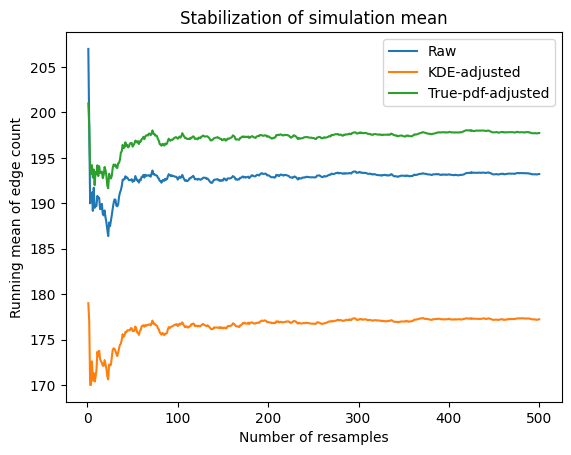

In [22]:
def summarize_counts(label, counts):
    mean = counts.mean()
    sd = counts.std(ddof=1)
    q025, q50, q975 = np.quantile(counts, [0.025, 0.5, 0.975])

    print(
        f"{label:>8} | mean = {mean:.2f} | sd = {sd:.2f} | "
        f"median = {q50:.2f} | 95% interval = [{q025:.2f}, {q975:.2f}]"
    )


for n_points in [50, 100, 250]:
    print(f"\nn_points = {n_points}")

    edge_counts_raw = edge_count_sim(
        n_points=n_points,
        t=1,
        n_resamples=500,
        d=3,
        p=0.8,
        direction=[1, 0, 0],
        seed=234,
    )

    edge_counts_kde = edge_count_sim_kde(
        n_points=n_points,
        t=1,
        n_resamples=500,
        d=3,
        p=0.8,
        h=0.15,
        direction=[1, 0, 0],
        seed=234,
    )

    edge_counts_pdf = edge_count_sim_pdf(
        n_points=n_points,
        t=1,
        n_resamples=500,
        d=3,
        p=0.8,
        direction=[1, 0, 0],
        seed=234,
    )

    summarize_counts("raw", edge_counts_raw)
    summarize_counts("kde", edge_counts_kde)
    summarize_counts("pdf", edge_counts_pdf)


# running mean comparison for one fixed n_points
n_points = 200
n_resamples = 500

edge_counts_raw = edge_count_sim(
    n_points=n_points,
    t=1,
    n_resamples=n_resamples,
    d=3,
    p=0.8,
    direction=[1, 0, 0],
    seed=234,
)

edge_counts_kde = edge_count_sim_kde(
    n_points=n_points,
    t=1,
    n_resamples=n_resamples,
    d=3,
    p=0.8,
    h=0.15,
    direction=[1, 0, 0],
    seed=234,
)

edge_counts_pdf = edge_count_sim_pdf(
    n_points=n_points,
    t=1,
    n_resamples=n_resamples,
    d=3,
    p=0.8,
    direction=[1, 0, 0],
    seed=234,
)

k = np.arange(1, n_resamples + 1)

running_mean_raw = np.cumsum(edge_counts_raw) / k
running_mean_kde = np.cumsum(edge_counts_kde) / k
running_mean_pdf = np.cumsum(edge_counts_pdf) / k

plt.plot(k, running_mean_raw, label="Raw")
plt.plot(k, running_mean_kde, label="KDE-adjusted")
plt.plot(k, running_mean_pdf, label="True-pdf-adjusted")
plt.xlabel("Number of resamples")
plt.ylabel("Running mean of edge count")
plt.title("Stabilization of simulation mean")
plt.legend()
plt.show()
#We should see more edges with the KDE than PDF

In [23]:
#Counting Edges, also calculating the density (edges in manifold)/ (Total_Possible Edges)
def count_edges(
    X: np.ndarray,
    t: float,
    D: np.ndarray | None = None,
    d: int | None = None,
    return_density: bool = True
):
    X = np.asarray(X, dtype=float)
    n = X.shape[0]

    # infer intrinsic dimension
    if d is None:
        d = X.shape[1]

    # CRITICAL REGIME scaling
    epsilon = t / (n ** (1.0 / d))

    if D is None:
        D = vr.pairwise_dist(X)

    # raw edge count
    edges = int(np.count_nonzero(np.triu(D <= epsilon, k=1)))

    if not return_density:
        return edges

    # total possible edges
    total_possible = n * (n - 1) / 2

    # normalized edge density
    density = edges / total_possible

    return edges, density

In [24]:
import matplotlib.pyplot as plt


def sweep_t_histograms(
    t_values,
    n: int,
    trials: int = 100,
    seed: int = 0,
    bins: int = 20,
    max_print: int = 10
):
    d = 2
    #For loop to calculate diff eps for a list of t values 
    for t in t_values:
        eps = t / (n ** (1.0 / d))

        # Inititalizing vectors to hold our counts/density for each shape
        sphere_counts   = np.zeros(trials, dtype=int)
        torus_counts    = np.zeros(trials, dtype=int)

        sphere_density  = np.zeros(trials)
        torus_density   = np.zeros(trials)
        #For each trial we run our sample point cloud function
        for i in range(trials):
            X_s = vr.sample_point_cloud("sphere", n, ambient_dim=3, seed=seed + i)
            X_t = vr.sample_point_cloud("torus",  n, ambient_dim=3, seed=seed + 100000 + i)
            #Calculate the distance matrix for each point cloyd
            D_s = vr.pairwise_dist(X_s)
            D_t = vr.pairwise_dist(X_t)

            # --- Count the edges/calculate the denstiy for each  ---
            e_s, d_s = count_edges(X_s, t, D=D_s, d=2)
            e_t, d_t = count_edges(X_t, t, D=D_t, d=2)
            # Append to our vector 
            sphere_counts[i]  = e_s
            torus_counts[i]   = e_t

            sphere_density[i] = d_s
            torus_density[i]  = d_t

        # =========================
        #  RAW EDGE STATS
        # Calcualting the mean and std for the raw edge counts in each shape
        # =========================
        mu_s, std_s = sphere_counts.mean(), sphere_counts.std()
        mu_t, std_t = torus_counts.mean(), torus_counts.std()

        # =========================
        # DENSITY STATS
        # Calcualting the mean and std for the density for  each shape
        # =========================
        mu_sd, std_sd = sphere_density.mean(), sphere_density.std()
        mu_td, std_td = torus_density.mean(), torus_density.std()

        print("\n==============================")
        print(f"t = {t} | epsilon = {eps:.5f}")

        print("\n=== EDGE COUNT SUMMARY ===")
        print(f"Sphere: μ={mu_s:.2f}, σ={std_s:.2f}")
        print(f"Torus : μ={mu_t:.2f}, σ={std_t:.2f}")

        print("\n=== DENSITY SUMMARY ===")
        print(f"Sphere: μ={mu_sd:.6f}, σ={std_sd:.6f}")
        print(f"Torus : μ={mu_td:.6f}, σ={std_td:.6f}")

        # --- RAW VALUES ---
        print("\nSphere raw edge counts:")
        print(sphere_counts[:max_print])

        print("\nTorus raw edge counts:")
        print(torus_counts[:max_print])

        print("\nSphere densities:")
        print(sphere_density[:max_print])

        print("\nTorus densities:")
        print(torus_density[:max_print])
        #Calculating the difference between the means of the edgecounts and density 
        print(f"\nMean edge diff (Sphere - Torus): {mu_s - mu_t:.2f}")
        print(f"Mean density diff (Sphere - Torus): {mu_sd - mu_td:.6f}")

        # =========================
        # PLOT 1: EDGE COUNTS
        # =========================
        plt.figure()
        plt.hist(sphere_counts, bins=bins, alpha=0.5, label="Sphere")
        plt.hist(torus_counts, bins=bins, alpha=0.5, label="Torus")

        plt.axvline(mu_s, linestyle='dashed', label=f"Sphere μ={mu_s:.2f}")
        plt.axvline(mu_t, linestyle='dashed', label=f"Torus μ={mu_t:.2f}")

        plt.title(f"Edge Count Distribution (t={t}, n={n})")
        plt.xlabel("Edge Count")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

        # =========================
        #  PLOT 2: DENSITY
        # =========================
        plt.figure()
        plt.hist(sphere_density, bins=bins, alpha=0.5, label="Sphere")
        plt.hist(torus_density, bins=bins, alpha=0.5, label="Torus")

        plt.axvline(mu_sd, linestyle='dashed', label=f"Sphere μ={mu_sd:.6f}")
        plt.axvline(mu_td, linestyle='dashed', label=f"Torus μ={mu_td:.6f}")

        plt.title(f"Edge Density Distribution (t={t}, n={n})")
        plt.xlabel("Density")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

    return sphere_counts, torus_counts, sphere_density, torus_density


t = 0.5 | epsilon = 0.02236

=== EDGE COUNT SUMMARY ===
Sphere: μ=15.96, σ=3.78
Torus : μ=3.33, σ=1.78

=== DENSITY SUMMARY ===
Sphere: μ=0.000128, σ=0.000030
Torus : μ=0.000027, σ=0.000014

Sphere raw edge counts:
[18 19 14 19 13 15 16 17 21 21]

Torus raw edge counts:
[2 1 1 3 1 2 5 4 1 1]

Sphere densities:
[0.00014429 0.0001523  0.00011222 0.0001523  0.00010421 0.00012024
 0.00012826 0.00013627 0.00016834 0.00016834]

Torus densities:
[1.60320641e-05 8.01603206e-06 8.01603206e-06 2.40480962e-05
 8.01603206e-06 1.60320641e-05 4.00801603e-05 3.20641283e-05
 8.01603206e-06 8.01603206e-06]

Mean edge diff (Sphere - Torus): 12.63
Mean density diff (Sphere - Torus): 0.000101


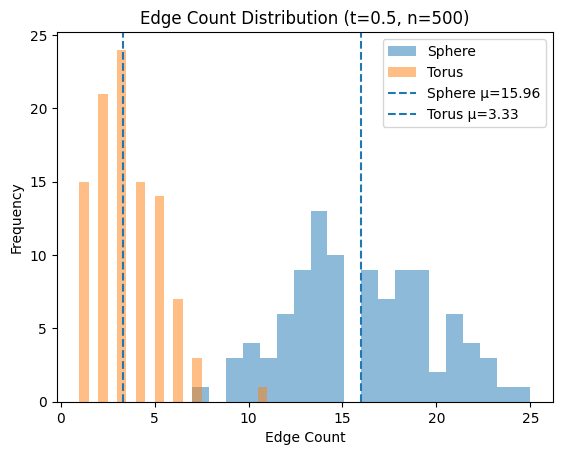

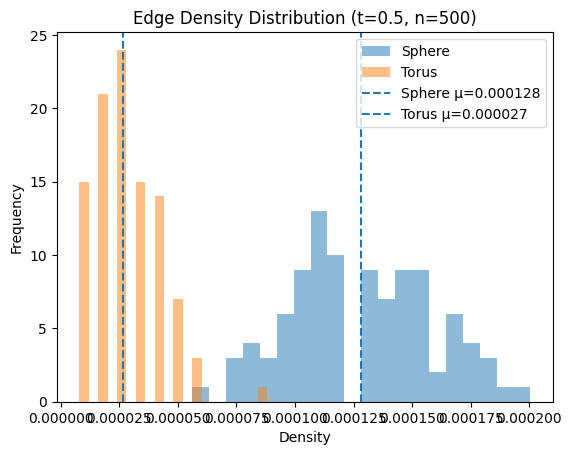


t = 1.0 | epsilon = 0.04472

=== EDGE COUNT SUMMARY ===
Sphere: μ=62.24, σ=6.93
Torus : μ=14.18, σ=3.92

=== DENSITY SUMMARY ===
Sphere: μ=0.000499, σ=0.000056
Torus : μ=0.000114, σ=0.000031

Sphere raw edge counts:
[67 57 68 63 66 77 56 69 78 52]

Torus raw edge counts:
[ 9 10 10 17 14 12 16 14 13 13]

Sphere densities:
[0.00053707 0.00045691 0.00054509 0.00050501 0.00052906 0.00061723
 0.0004489  0.00055311 0.00062525 0.00041683]

Torus densities:
[7.21442886e-05 8.01603206e-05 8.01603206e-05 1.36272545e-04
 1.12224449e-04 9.61923848e-05 1.28256513e-04 1.12224449e-04
 1.04208417e-04 1.04208417e-04]

Mean edge diff (Sphere - Torus): 48.06
Mean density diff (Sphere - Torus): 0.000385


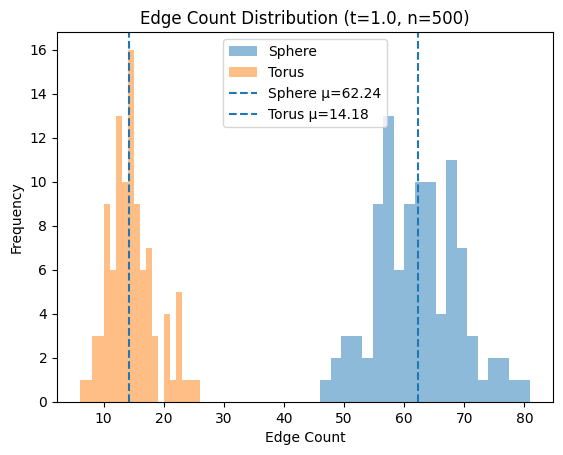

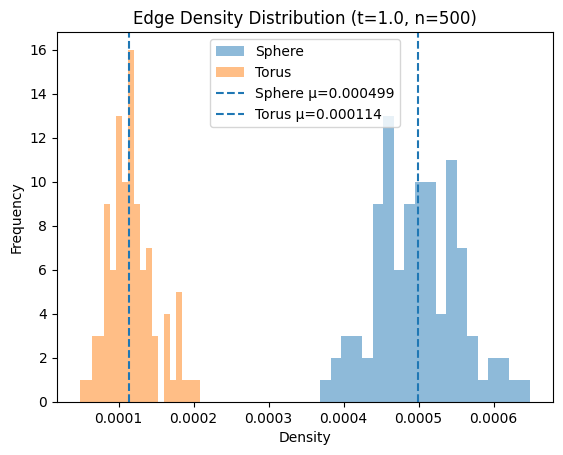


t = 1.5 | epsilon = 0.06708

=== EDGE COUNT SUMMARY ===
Sphere: μ=139.00, σ=9.98
Torus : μ=32.37, σ=5.41

=== DENSITY SUMMARY ===
Sphere: μ=0.001114, σ=0.000080
Torus : μ=0.000259, σ=0.000043

Sphere raw edge counts:
[126 139 148 135 149 160 119 148 152 123]

Torus raw edge counts:
[35 21 25 32 31 35 33 36 35 33]

Sphere densities:
[0.00101002 0.00111423 0.00118637 0.00108216 0.00119439 0.00128257
 0.00095391 0.00118637 0.00121844 0.00098597]

Torus densities:
[0.00028056 0.00016834 0.0002004  0.00025651 0.0002485  0.00028056
 0.00026453 0.00028858 0.00028056 0.00026453]

Mean edge diff (Sphere - Torus): 106.63
Mean density diff (Sphere - Torus): 0.000855


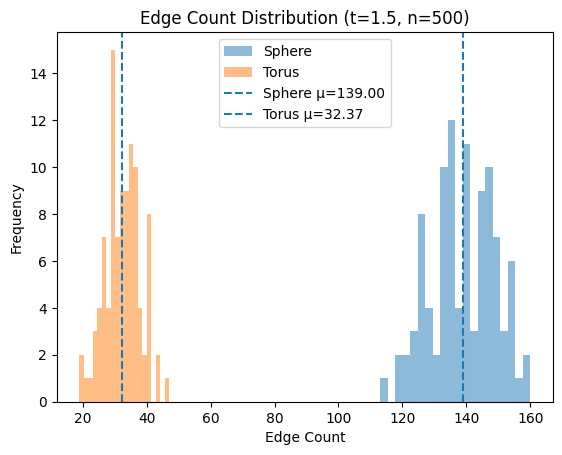

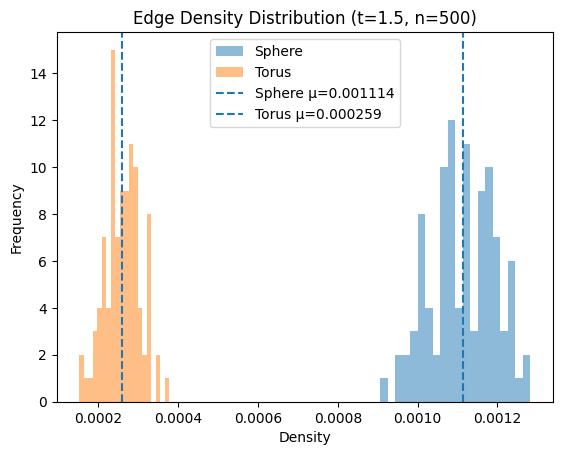


t = 2.0 | epsilon = 0.08944

=== EDGE COUNT SUMMARY ===
Sphere: μ=248.42, σ=13.15
Torus : μ=58.02, σ=7.09

=== DENSITY SUMMARY ===
Sphere: μ=0.001991, σ=0.000105
Torus : μ=0.000465, σ=0.000057

Sphere raw edge counts:
[232 251 278 260 250 248 225 272 248 228]

Torus raw edge counts:
[61 54 46 64 52 61 57 56 61 59]

Sphere densities:
[0.00185972 0.00201202 0.00222846 0.00208417 0.00200401 0.00198798
 0.00180361 0.00218036 0.00198798 0.00182766]

Torus densities:
[0.00048898 0.00043287 0.00036874 0.00051303 0.00041683 0.00048898
 0.00045691 0.0004489  0.00048898 0.00047295]

Mean edge diff (Sphere - Torus): 190.40
Mean density diff (Sphere - Torus): 0.001526


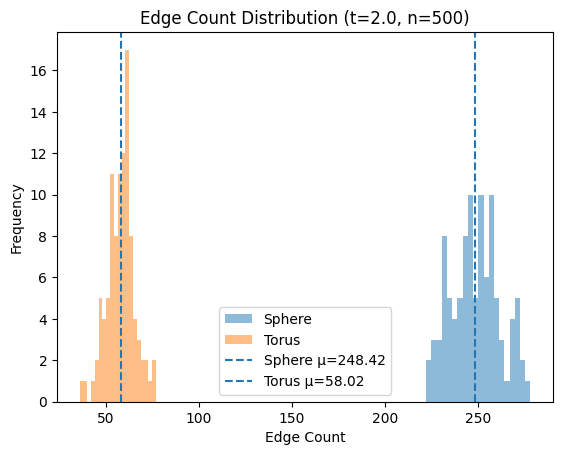

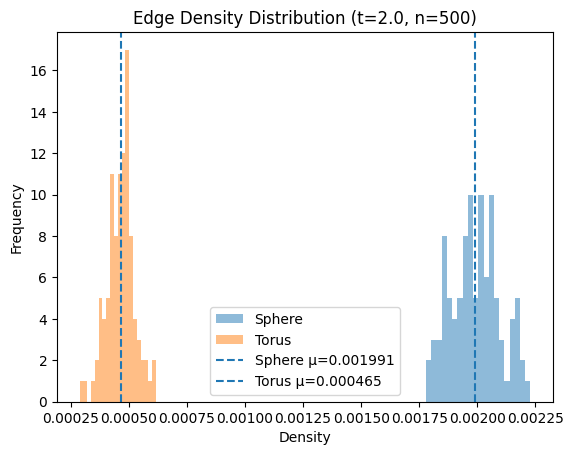


t = 2.5 | epsilon = 0.11180

=== EDGE COUNT SUMMARY ===
Sphere: μ=388.77, σ=17.92
Torus : μ=89.14, σ=8.87

=== DENSITY SUMMARY ===
Sphere: μ=0.003116, σ=0.000144
Torus : μ=0.000715, σ=0.000071

Sphere raw edge counts:
[382 391 412 389 397 376 371 411 376 368]

Torus raw edge counts:
[ 94  78  71  92  87  92  89  83  94 100]

Sphere densities:
[0.00306212 0.00313427 0.00330261 0.00311824 0.00318236 0.00301403
 0.00297395 0.00329459 0.00301403 0.0029499 ]

Torus densities:
[0.00075351 0.00062525 0.00056914 0.00073747 0.00069739 0.00073747
 0.00071343 0.00066533 0.00075351 0.0008016 ]

Mean edge diff (Sphere - Torus): 299.63
Mean density diff (Sphere - Torus): 0.002402


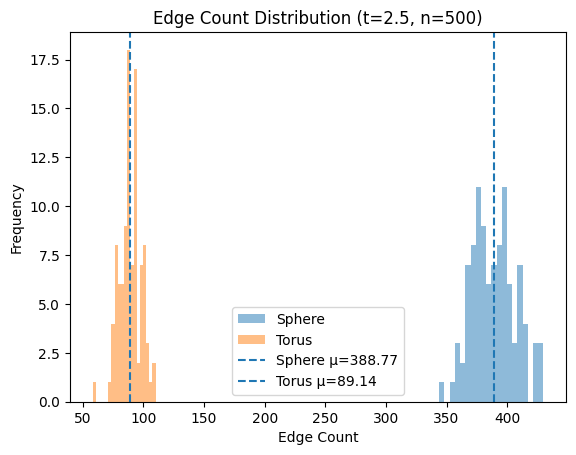

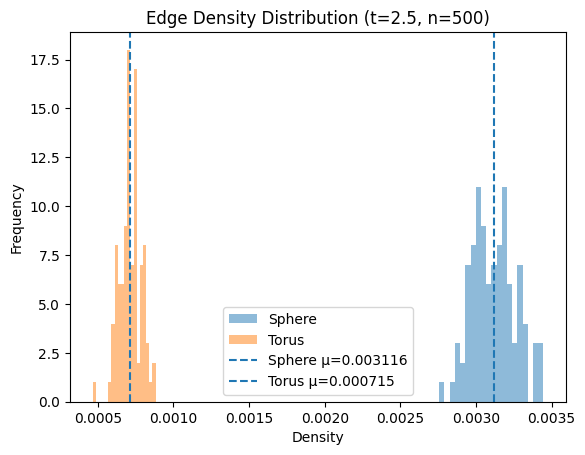

(array([382, 391, 412, 389, 397, 376, 371, 411, 376, 368, 411, 379, 381,
        384, 417, 406, 356, 393, 372, 378, 372, 375, 398, 385, 391, 397,
        382, 366, 368, 395, 382, 379, 392, 372, 344, 406, 375, 406, 370,
        378, 387, 410, 397, 396, 395, 402, 399, 422, 383, 377, 400, 397,
        409, 426, 411, 366, 401, 385, 366, 404, 396, 394, 422, 395, 401,
        382, 430, 378, 371, 390, 422, 413, 371, 393, 380, 428, 397, 367,
        361, 383, 392, 365, 417, 415, 376, 412, 375, 360, 388, 388, 370,
        381, 383, 396, 360, 363, 398, 377, 403, 368]),
 array([ 94,  78,  71,  92,  87,  92,  89,  83,  94, 100,  86,  82,  83,
        110,  82,  96,  84,  91, 100,  77,  81,  93,  89, 100,  84,  76,
         93,  85,  81,  82,  89,  90,  81,  74,  85, 104,  82,  92,  92,
         74,  89,  85,  79,  88, 103,  90,  77,  89,  86,  93,  94,  98,
        105,  97,  92,  90, 104,  77,  80,  78,  89,  58, 101,  87,  94,
         94,  96,  86,  77,  88, 110,  88,  89,  98,  92,  97,  88,  

In [25]:
#Creating a list of T values we want to try
t_values = [0.5, 1.0, 1.5, 2.0, 2.5]
#Running our function that runs the simulations
# Give it our t values, n= number of points in point cloud, number of trials and our seed so we can reproduce results
sweep_t_histograms(
    t_values=t_values,
    n=500,
    trials=100,
    seed=0
)

In [26]:
#clear speration between the edge count dist of Sphere and Torus,
#lets build a simple classifer
def simple_threshold_classifier(sphere_counts, torus_counts):
    # choose threshold halfway between means
    mu_s = sphere_counts.mean()
    mu_t = torus_counts.mean()
    threshold = (mu_s + mu_t) / 2

    print(f"Threshold = {threshold:.2f}")
    
    #Once our threshold has been set a simple decision rule is set up
    #"greater than or less than" rule to predict what a shape is:If a point cloud has more edges than the threshold: It’s classified as a Sphere.
    #If a point cloud has fewer edges than the threshold: It’s classified as a Torus.
    sphere_pred = sphere_counts > threshold
    torus_pred  = torus_counts > threshold
    # evaluate accuracy
    sphere_acc = np.mean(sphere_pred == 1)  # should be True
    torus_acc  = np.mean(torus_pred == 0)   # should be False

    print(f"Sphere accuracy: {sphere_acc:.3f}")
    print(f"Torus accuracy : {torus_acc:.3f}")
    print(f"Overall accuracy: {(sphere_acc + torus_acc)/2:.3f}")

    return threshold


t = 0.25 | epsilon = 0.01118

=== EDGE COUNT SUMMARY ===
Sphere: μ=3.96, σ=2.11
Torus : μ=0.74, σ=0.83

=== DENSITY SUMMARY ===
Sphere: μ=0.000032, σ=0.000017
Torus : μ=0.000006, σ=0.000007

Sphere raw edge counts:
[3 5 4 4 1 7 5 4 6 6]

Torus raw edge counts:
[1 1 1 0 0 0 2 1 0 0]

Sphere densities:
[2.40480962e-05 4.00801603e-05 3.20641283e-05 3.20641283e-05
 8.01603206e-06 5.61122244e-05 4.00801603e-05 3.20641283e-05
 4.80961924e-05 4.80961924e-05]

Torus densities:
[8.01603206e-06 8.01603206e-06 8.01603206e-06 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.60320641e-05 8.01603206e-06
 0.00000000e+00 0.00000000e+00]

Mean edge diff (Sphere - Torus): 3.22
Mean density diff (Sphere - Torus): 0.000026


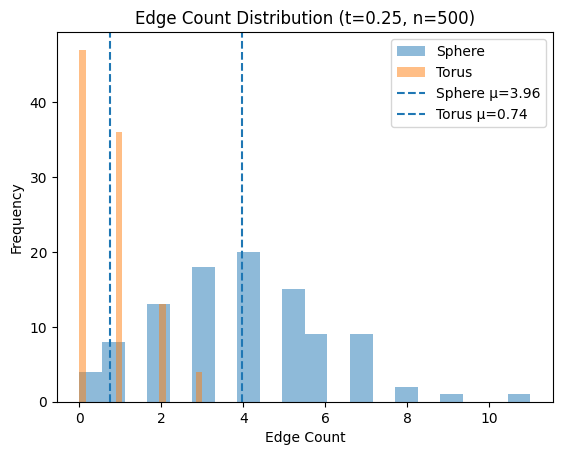

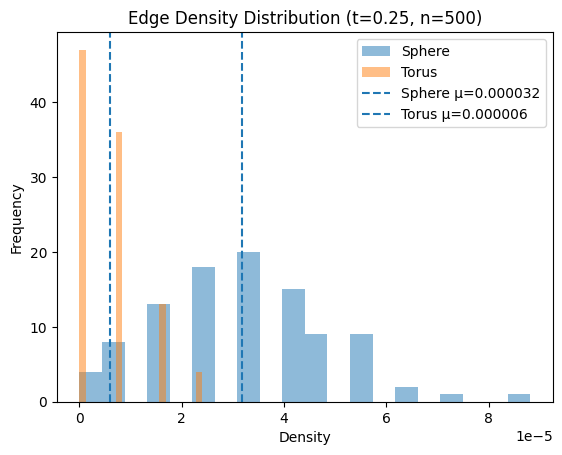

Threshold = 2.35
Sphere accuracy: 0.750
Torus accuracy : 0.960
Overall accuracy: 0.855


In [27]:
# 1. Run the sweep
s_counts, t_counts,_,_ = sweep_t_histograms(t_values=[0.25], n=500)

# 2. Now the classifier uses the exact data you just saw on the screen
threshold = simple_threshold_classifier(s_counts, t_counts)
#For bigger T(eps) the edge counts are very noticable so its 100% accurate all the time, very basic but groundwork for later work

In [28]:
#more robust clasifier
# take a single point cloud X and convert it into a feature vector.
def extract_features(X, t_values):
    """
    Multiscale geometric features using edge density + growth.
    """
    feats = []

    D = vr.pairwise_dist(X)
    n = X.shape[0]
    total_possible = n * (n - 1) / 2

    densities = []

    # --- compute densities ---
    for t in t_values:
        eps = t / (n ** 0.5)  # d=2

        edges = np.count_nonzero(np.triu(D <= eps, k=1))
        density = edges / total_possible

        densities.append(density)

    densities = np.array(densities)

    # --- features ---
    feats.extend(densities)

    # --- add growth (differences between scales) ---
    growth = np.diff(densities)
    feats.extend(growth)

    return np.array(feats)

In [29]:
#Training data, data turned into table where each row is trial, each col is a t val and a new col where we know whether its a sphere(1) or torus(0)
def build_dataset(t_values, n=500, trials=100, seed=0):
    X_data = []
    y_data = []

    for i in range(trials):
        X_s = vr.sample_point_cloud("sphere", n, ambient_dim=3, seed=seed + i)
        X_t = vr.sample_point_cloud("torus",  n, ambient_dim=3, seed=seed + i)

        feat_s = extract_features(X_s, t_values)
        feat_t = extract_features(X_t, t_values)

        X_data.append(feat_s)
        y_data.append(1)

        X_data.append(feat_t)
        y_data.append(0)

    return np.array(X_data), np.array(y_data)

In [30]:
#2 rows shuffled up 0.7 used for training, 0.3 used for testing
def train_test_split(X, y, split=0.7):
    idx = np.random.permutation(len(X))

    train_size = int(split * len(X))

    train_idx = idx[:train_size]
    test_idx = idx[train_size:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [31]:
#each class becomes a single point in feature space
#find the prototype for each t, then use euclidian distance to find which point is closer and classify
def nearest_centroid(X_train, y_train, X_test):
    mu_s = X_train[y_train == 1].mean(axis=0)
    mu_t = X_train[y_train == 0].mean(axis=0)

    preds = []

    for x in X_test:
        d_s = np.linalg.norm(x - mu_s)
        d_t = np.linalg.norm(x - mu_t)

        preds.append(1 if d_s < d_t else 0)

    return np.array(preds)

In [32]:
t_values = [0.5,0.75,1]

X, y = build_dataset(t_values, n=200, trials=100)

X_train, X_test, y_train, y_test = train_test_split(X, y)

y_pred = nearest_centroid(X_train, y_train, X_test)

print("Accuracy:", np.mean(y_pred == y_test))

Accuracy: 1.0


In [34]:
def sweep_t_histograms_2(
    t_values,
    n: int,
    trials: int = 100,
    seed: int = 0,
    bins: int = 20,
    max_print: int = 10
):
    d = 2

    for t in t_values:
        eps = t / (n ** (1.0 / d))

        # --- storage ---
        sphere_counts   = np.zeros(trials, dtype=int)
        cylinder_counts = np.zeros(trials, dtype=int)

        sphere_density  = np.zeros(trials)
        cylinder_density = np.zeros(trials)

        for i in range(trials):
            X_s = vr.sample_point_cloud("sphere", n, ambient_dim=3, seed=seed + i)
            X_c = vr.sample_point_cloud("Cylinder", n, ambient_dim=3, seed=seed + 100000 + i)

            D_s = vr.pairwise_dist(X_s)
            D_c = vr.pairwise_dist(X_c)

            # ---  unpack edges + density ---
            e_s, d_s = count_edges(X_s, t, D=D_s, d=2)
            e_c, d_c = count_edges(X_c, t, D=D_c, d=2)

            sphere_counts[i]   = e_s
            cylinder_counts[i] = e_c

            sphere_density[i]  = d_s
            cylinder_density[i] = d_c

        # =========================
        # EDGE STATS
        # =========================
        mu_s, std_s = sphere_counts.mean(), sphere_counts.std()
        mu_c, std_c = cylinder_counts.mean(), cylinder_counts.std()

        # =========================
        # DENSITY STATS
        # =========================
        mu_sd, std_sd = sphere_density.mean(), sphere_density.std()
        mu_cd, std_cd = cylinder_density.mean(), cylinder_density.std()

        print("\n==============================")
        print(f"t = {t} | epsilon = {eps:.5f}")

        print("\n=== EDGE COUNT SUMMARY ===")
        print(f"Sphere:   μ={mu_s:.2f}, σ={std_s:.2f}")
        print(f"Cylinder: μ={mu_c:.2f}, σ={std_c:.2f}")

        print("\n=== DENSITY SUMMARY ===")
        print(f"Sphere:   μ={mu_sd:.6f}, σ={std_sd:.6f}")
        print(f"Cylinder: μ={mu_cd:.6f}, σ={std_cd:.6f}")

        # --- RAW VALUES ---
        print("\nSphere raw edge counts:")
        print(sphere_counts[:max_print])

        print("\nCylinder raw edge counts:")
        print(cylinder_counts[:max_print])

        print("\nSphere densities:")
        print(sphere_density[:max_print])

        print("\nCylinder densities:")
        print(cylinder_density[:max_print])

        print(f"\nMean edge diff (Sphere - Cylinder): {mu_s - mu_c:.2f}")
        print(f"Mean density diff (Sphere - Cylinder): {mu_sd - mu_cd:.6f}")

        # =========================
        # PLOT 1: EDGE COUNTS
        # =========================
        plt.figure()
        plt.hist(sphere_counts, bins=bins, alpha=0.5, label="Sphere")
        plt.hist(cylinder_counts, bins=bins, alpha=0.5, label="Cylinder")

        plt.axvline(mu_s, linestyle='dashed', label=f"Sphere μ={mu_s:.2f}")
        plt.axvline(mu_c, linestyle='dashed', label=f"Cylinder μ={mu_c:.2f}")

        plt.title(f"Edge Count Distribution (t={t}, n={n})")
        plt.xlabel("Edge Count")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

        # =========================
        #  PLOT 2: DENSITY
        # =========================
        plt.figure()
        plt.hist(sphere_density, bins=bins, alpha=0.5, label="Sphere")
        plt.hist(cylinder_density, bins=bins, alpha=0.5, label="Cylinder")

        plt.axvline(mu_sd, linestyle='dashed', label=f"Sphere μ={mu_sd:.6f}")
        plt.axvline(mu_cd, linestyle='dashed', label=f"Cylinder μ={mu_cd:.6f}")

        plt.title(f"Edge Density Distribution (t={t}, n={n})")
        plt.xlabel("Density")
        plt.ylabel("Frequency")
        plt.legend()
        plt.show()

    return sphere_counts, cylinder_counts, sphere_density, cylinder_density


t = 1 | epsilon = 0.10000

=== EDGE COUNT SUMMARY ===
Sphere:   μ=12.28, σ=2.98
Cylinder: μ=12.53, σ=3.41

=== DENSITY SUMMARY ===
Sphere:   μ=0.002481, σ=0.000601
Cylinder: μ=0.002531, σ=0.000690

Sphere raw edge counts:
[ 7 13  8 13 10 13 19  9  9 13]

Cylinder raw edge counts:
[13 13 14 12 12 18 19  7 17 13]

Sphere densities:
[0.00141414 0.00262626 0.00161616 0.00262626 0.0020202  0.00262626
 0.00383838 0.00181818 0.00181818 0.00262626]

Cylinder densities:
[0.00262626 0.00262626 0.00282828 0.00242424 0.00242424 0.00363636
 0.00383838 0.00141414 0.00343434 0.00262626]

Mean edge diff (Sphere - Cylinder): -0.25
Mean density diff (Sphere - Cylinder): -0.000051


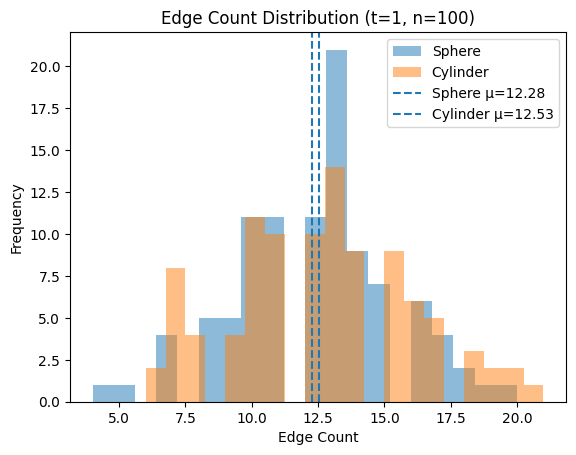

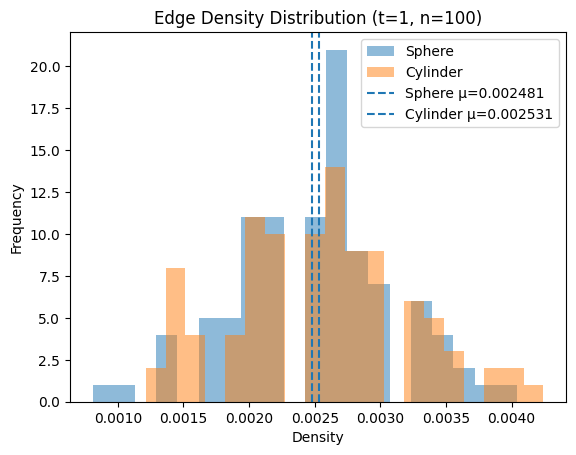

Threshold = 12.40
Sphere accuracy: 0.510
Torus accuracy : 0.490
Overall accuracy: 0.500


In [35]:
# 1. Run the sweep
s_counts, c_counts,_,_ = sweep_t_histograms_2(t_values=[1], n=100)
# 2. Now the classifier uses the exact data you just saw on the screen
threshold = simple_threshold_classifier(s_counts, c_counts)

In [36]:

#more robust clasifier
#Pipeline for our classification model
# take a single point cloud X and convert it into a feature vector.
def extract_features(X, t_values):
    """
    Multiscale geometric features using edge density + growth.
    """
    #initializing our features list
    feats = []

    D = vr.pairwise_dist(X)
    n = X.shape[0]
    total_possible = n * (n - 1) / 2


    densities = []

    # --- compute densities ---
    #We are going to be look at a sequence of graphs of different t values
    for t in t_values:
        eps = t / (n ** 0.5)  # d=2

        edges = np.count_nonzero(np.triu(D <= eps, k=1))
        density = edges / total_possible

        densities.append(density)
    #Using density instead of raw edge counts for predictor
    densities = np.array(densities)

    # --- features ---
    feats.extend(densities)
    
    # --- add growth (differences between scales) ---
    #density(t2) - density(t1)
    #density(t3) - density(t2)
    #Trying to capture growth of geomtetric change
    growth = np.diff(densities)
    feats.extend(growth)
    

    return np.array(feats)
#So we have 2 features that are going to be used our predictors(Density,Growth change)
#[d1, d2, d3, ..., g1, g2, ...]
#We should expect different growth patterns since they are diff shapes 

In [37]:
#Training data, data turned into table where each row is trial, each col is a t val and a new col where we know whether its a sphere(1) or torus(0)
def build_dataset(t_values, n=500, trials=100, seed=0):
    #feature vector
    X_data = []
    #labels
    y_data = []
    #for each trial, we are going to compute a point cloud where we sample from 2 distributions, sphere = 1, cyclinder = 0
    for i in range(trials):
        X_s = vr.sample_point_cloud("sphere", n, ambient_dim=3, seed=seed + i)
        X_c = vr.sample_point_cloud("Cylinder",  n, ambient_dim=3, seed=seed + 100000 + i)
        #Each point cloud becomes a vector containing its density and growth
        feat_s = extract_features(X_s, t_values)
        feat_c = extract_features(X_c, t_values)
        #Sphere features
        X_data.append(feat_s)
        #Create its label(1 for sphere)
        y_data.append(1)
        #Cylinder features
        X_data.append(feat_c)
        # Create its label(0 for cylinder)
        y_data.append(0)
    #convert to numpy arrays
    return np.array(X_data), np.array(y_data)

In [38]:
#New step Standardizing our data
#Each col has mean around 0 and std around 1
def standardize(X_train, X_test):
    mu = X_train.mean(axis=0)
    std = X_train.std(axis=0) + 1e-8

    return (X_train - mu)/std, (X_test - mu)/std

In [39]:
#2 rows shuffled up 0.7 used for training, 0.3 used for testing
def train_test_split(X, y, split=0.7):
    idx = np.random.permutation(len(X))

    train_size = int(split * len(X))

    train_idx = idx[:train_size]
    test_idx = idx[train_size:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [40]:
def nearest_centroid(X_train, y_train, X_test):
    # if a sphere average feature vector for all spheres
    mu_s = X_train[y_train == 1].mean(axis=0)
    # if a cylinder average feature vector for all cylinders 
    mu_c = X_train[y_train == 0].mean(axis=0)

    preds = []
    #euclidian distance 
    # for each point check if closer to sphere predict 1 and closer to cylinder predict 0
    for x in X_test:
        d_s = np.linalg.norm(x - mu_s)
        d_c = np.linalg.norm(x - mu_c)

        preds.append(1 if d_s < d_c else 0)

    return np.array(preds)

In [41]:
#Testing
#Each T becomes a feature
t_values = [1,2,3]

X, y = build_dataset(t_values, n=100, trials=100)

X_train, X_test, y_train, y_test = train_test_split(X, y)

X_train, X_test = standardize(X_train, X_test)

y_pred = nearest_centroid(X_train, y_train, X_test)

print("Accuracy:", np.mean(y_pred == y_test))

Accuracy: 0.6833333333333333


In [43]:
from sklearn.decomposition import PCA

def plot_feature_space(X, y):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plt.figure()

    plt.scatter(X_2d[y==1,0], X_2d[y==1,1], label="Sphere", alpha=0.6)
    plt.scatter(X_2d[y==0,0], X_2d[y==0,1], label="Cylinder", alpha=0.6)

    plt.title("ECC Feature Space (PCA Projection)")
    plt.legend()
    plt.show()

In [44]:
def plot_average_signature(X, y, t_values):
    sphere = X[y==1].mean(axis=0)
    cylinder = X[y==0].mean(axis=0)

    plt.figure()

    plt.plot(sphere[:len(t_values)], label="Sphere densities")
    plt.plot(cylinder[:len(t_values)], label="Cylinder densities")

    plt.title("Average ECC Filtration Signature")
    plt.legend()
    plt.show()

In [45]:
def plot_growth(X, y, t_values):
    k = len(t_values)

    sphere_growth = X[y==1][:, k:]
    cylinder_growth = X[y==0][:, k:]

    plt.figure()

    plt.plot(sphere_growth.mean(axis=0), label="Sphere growth")
    plt.plot(cylinder_growth.mean(axis=0), label="Cylinder growth")

    plt.title("ECC Growth Features")
    plt.legend()
    plt.show()

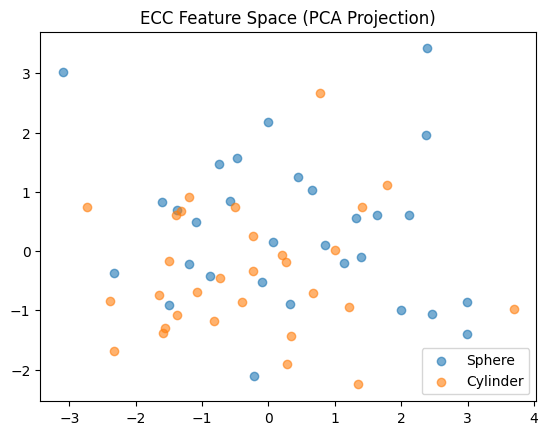

In [49]:
plot_feature_space(X_test, y_test)

In [50]:
#Experiment for differnent values of N and T

In [51]:
def run_experiment(n, t_values, trials=100, seed=0):
    X, y = build_dataset(t_values, n=n, trials=trials, seed=seed)

    X_train, X_test, y_train, y_test = train_test_split(X, y)

    X_train, X_test = standardize(X_train, X_test)

    y_pred = nearest_centroid(X_train, y_train, X_test)

    acc = np.mean(y_pred == y_test)

    return acc

In [52]:
def sweep_n_t(n_values, t_sets, trials=100):
    results = {}

    for t_values in t_sets:
        key = tuple(t_values)
        results[key] = []

        print("\n==============================")
        print(f"t_values = {t_values}")

        for n in n_values:
            acc = run_experiment(n, t_values, trials=trials)

            results[key].append(acc)

            print(f"n = {n} → Accuracy = {acc:.3f}")

    return results

In [53]:
def plot_results(n_values, results):
    import matplotlib.pyplot as plt

    plt.figure()

    for t_values, accs in results.items():
        plt.plot(n_values, accs, marker='o', label=f"t={t_values}")

    plt.xlabel("n (number of points)")
    plt.ylabel("Accuracy")
    plt.title("Classifier Performance vs n and t")
    plt.legend()
    plt.show()


t_values = [0.5, 0.75, 1.0]
n = 50 → Accuracy = 0.467
n = 100 → Accuracy = 0.517
n = 200 → Accuracy = 0.500
n = 500 → Accuracy = 0.383

t_values = [1.0, 1.5, 2.0]
n = 50 → Accuracy = 0.533
n = 100 → Accuracy = 0.467
n = 200 → Accuracy = 0.600
n = 500 → Accuracy = 0.550

t_values = [2.0, 3.0, 5.0]
n = 50 → Accuracy = 0.850
n = 100 → Accuracy = 0.817
n = 200 → Accuracy = 0.750
n = 500 → Accuracy = 0.817


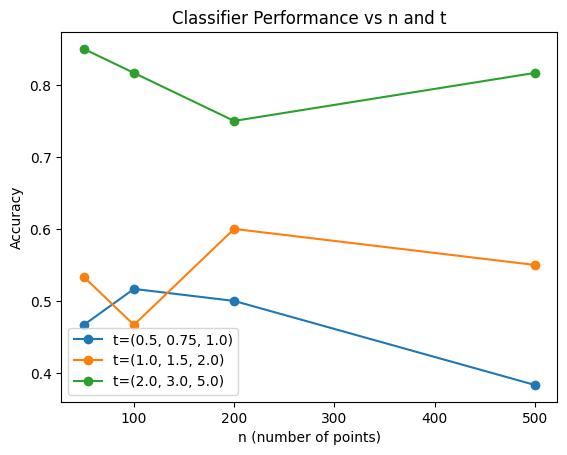

In [54]:
n_values = [50, 100, 200, 500]

t_sets = [
    [0.5, 0.75, 1.0],
    [1.0, 1.5, 2.0],
    [2.0, 3.0, 5.0]
]

results = sweep_n_t(n_values, t_sets, trials=100)

plot_results(n_values, results)